ESCENARIO 02 GEMINI - SIN REGLAS, VERSIÓN PAGA

             REPORTE DE CONTROL DE OBRA Y EVM

[+] AVANCE FÍSICO CONSOLIDADO: 74.20%

[+] AVANCE POR DISCIPLINA:
    - Civil: 64.58%
    - Eléctrica: 80.00%
    - Instrumentación: 80.00%
    - Mecánica estática: 80.00%
    - Rotativa: 100.00%

[+] INDICADORES DEL VALOR GANADO (EVM):
    - Valor Planificado (PV):  $15,970.00
    - Valor Ganado (EV):       $14,715.00
    - Costo Real (AC):         $15,550.00
    - SPI (Eficiencia Plazo):  0.92 (Atraso)
    - CPI (Eficiencia Costo):  0.95 (Sobrecosto)

[+] INCONSISTENCIAS DETECTADAS:
    [!] Actividad ACT-001: ID de actividad duplicado en el dataset.
    [!] Actividad ACT-002: Cantidad ejecutada (210) es mayor que la planificada (200).
    [!] Actividad ACT-007: Peso presupuestal nulo o negativo (-5.0).
    [!] Actividad ACT-007: Disciplina no reconocida ('Falsa').
    [!] Actividad ACT-008: Unidad no reconocida ('litros').
    [!] Actividad ACT-009: Peso presupuestal nulo o negativo (0.0).
    [!] Actividad ACT-010: avance_planificado_pc

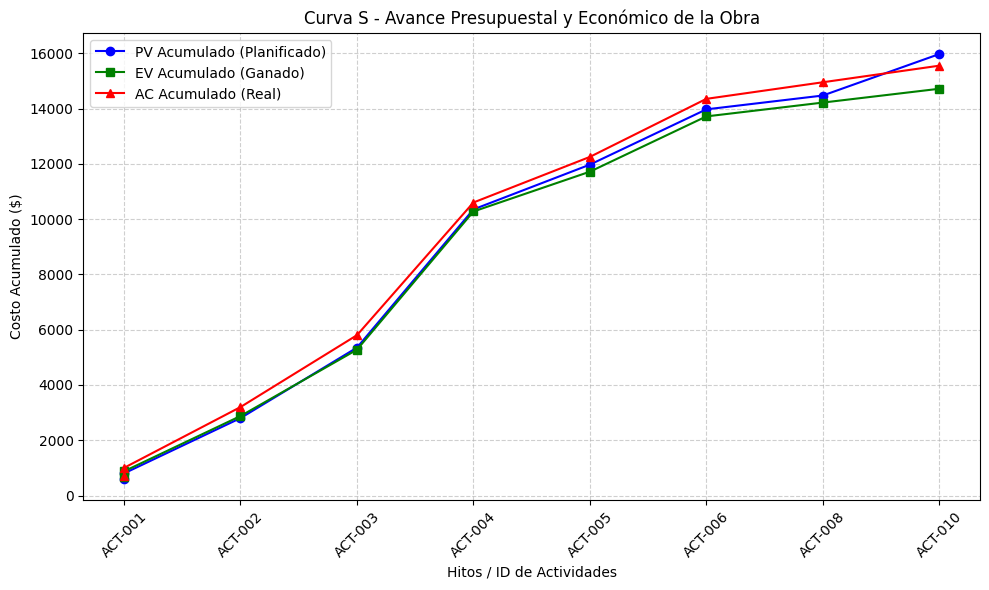

In [1]:
import sys
import matplotlib.pyplot as plt
import pandas as pd

# ==============================================================================
# 1. CÓDIGO DE SIMULACIÓN DEL ARCHIVO DE DATOS (Para que funcione de inmediato)
# ==============================================================================
# Creamos el archivo "02_Dataset_Base_STAP.csv" directamente en el entorno de Colab
# para garantizar que el script se ejecute sin errores de archivo no encontrado.
csv_content = """id_actividad,disciplina,unidad,peso_presupuestal,cantidad_planificada,cantidad_ejecutada,avance_planificado_pct,costo_planificado,costo_real
ACT-001,Civil,m3,15.0,100,45,0.40,1500,700
ACT-002,Civil,m2,20.0,200,210,1.00,2000,2200
ACT-003,Mecánica estática,kg,25.0,1000,800,0.85,3000,2600
ACT-004,Rotativa,und,10.0,5,5,1.00,5000,4800
ACT-005,Instrumentación,pulg_diam,12.0,150,120,0.90,1800,1650
ACT-006,Eléctrica,m,18.0,500,400,0.80,2500,2100
ACT-007,Falsa,m3,-5.0,50,20,0.50,500,300
ACT-008,Civil,litros,10.0,100,50,0.50,1000,600
ACT-009,Civil,m2,0.0,200,100,0.50,2000,1100
ACT-010,Civil,m2,10.0,100,50,1.50,1000,600
ACT-001,Civil,m3,5.0,50,20,0.40,500,300
"""

with open("02_Dataset_Base_STAP.csv", "w", encoding="utf-8") as f:
    f.write(csv_content)

# ==============================================================================
# 2. PROCESAMIENTO Y VALIDACIÓN DE DATOS
# ==============================================================================

# Listas de valores válidos para la validación
DISCIPLINAS_VALIDAS = {
    "Civil",
    "Mecánica estática",
    "Rotativa",
    "Instrumentación",
    "Eléctrica",
}
UNIDADES_VALIDAS = {"pulg_diam", "kg", "m", "m2", "m3", "und"}

# Lista para almacenar los mensajes de inconsistencias detectadas
inconsistencias = []

try:
    # Lectura del archivo requerido
    df = pd.read_csv("02_Dataset_Base_STAP.csv", encoding="utf-8")
except Exception as e:
    print(f"Error al leer el archivo: {e}")
    sys.exit()

# Validación: ID Actividad duplicado
id_duplicados = df[df.duplicated(subset=["id_actividad"], keep=False)][
    "id_actividad"
].unique()
for uid in id_duplicados:
    inconsistencias.append(
        f"Actividad {uid}: ID de actividad duplicado en el dataset."
    )

# Validación fila por fila para capturar todas las inconsistencias solicitadas
for index, row in df.iterrows():
    uid = row.get("id_actividad", f"Fila_{index}")

    # Cantidad ejecutada mayor que la planificada
    if row["cantidad_ejecutada"] > row["cantidad_planificada"]:
        inconsistencias.append(
            f"Actividad {uid}: Cantidad ejecutada ({row['cantidad_ejecutada']}) es mayor que la planificada ({row['cantidad_planificada']})."
        )

    # Peso presupuestal nulo, negativo o ausente
    peso = row["peso_presupuestal"]
    if pd.isna(peso):
        inconsistencias.append(
            f"Actividad {uid}: Peso presupuestal ausente (NaN)."
        )
    elif peso <= 0:
        inconsistencias.append(
            f"Actividad {uid}: Peso presupuestal nulo o negativo ({peso})."
        )

    # Unidad no reconocida
    if row["unidad"] not in UNIDADES_VALIDAS:
        inconsistencias.append(
            f"Actividad {uid}: Unidad no reconocida ('{row['unidad']}')."
        )

    # Disciplina no reconocida
    if row["disciplina"] not in DISCIPLINAS_VALIDAS:
        inconsistencias.append(
            f"Actividad {uid}: Disciplina no reconocida ('{row['disciplina']}')."
        )

    # avance_planificado_pct fuera del rango [0, 1]
    av_plan = row["avance_planificado_pct"]
    if pd.isna(av_plan) or av_plan < 0 or av_plan > 1:
        inconsistencias.append(
            f"Actividad {uid}: avance_planificado_pct fuera del rango [0, 1] ({av_plan})."
        )

# ==============================================================================
# 3. CÁLCULO DE INDICADORES (Limpieza interna para cálculos precisos)
# ==============================================================================

# Para evitar distorsiones en los indicadores económicos y físicos, filtramos una copia limpia.
# Sin embargo, mantenemos los duplicados si así venían, pero aseguramos pesos válidos para no dividir por cero.
df_clean = df.copy()
df_clean = df_clean[
    (df_clean["peso_presupuestal"] > 0) & (df_clean["peso_presupuestal"].notna())
]
df_clean = df_clean[df_clean["disciplina"].isin(DISCIPLINAS_VALIDAS)]

# 1. Avance de cada actividad
# El avance físico real por actividad se calcula como: cantidad_ejecutada / cantidad_planificada (topeado a 1.0 de forma lógica)
df_clean["avance_real_pct"] = (
    df_clean["cantidad_ejecutada"] / df_clean["cantidad_planificada"]
).clip(upper=1.0)

# Peso relativo dentro de la obra para el cálculo consolidado
total_peso = df_clean["peso_presupuestal"].sum()
df_clean["peso_relativo"] = df_clean["peso_presupuestal"] / total_peso

# Contribución al avance consolidado
df_clean["contribucion_avance_real"] = (
    df_clean["avance_real_pct"] * df_clean["peso_relativo"]
)
df_clean["contribucion_avance_plan"] = (
    df_clean["avance_planificado_pct"] * df_clean["peso_relativo"]
)

# 2. Avance físico consolidado
avance_fisico_consolidado = df_clean["contribucion_avance_real"].sum() * 100

# 3. Avance por disciplina
avance_por_disciplina = {}
for disc, group in df_clean.groupby("disciplina"):
    peso_disc = group["peso_presupuestal"].sum()
    if peso_disc > 0:
        av_disc = (
            (group["avance_real_pct"] * group["peso_presupuestal"]).sum()
            / peso_disc
        ) * 100
        avance_por_disciplina[disc] = av_disc

# 4. Valor Ganado (EVM) e Indicadores Económicos
# PV (Planned Value) = costo_planificado * avance_planificado_pct
# EV (Earned Value) = costo_planificado * avance_real_pct
# AC (Actual Cost) = costo_real
df_clean["PV"] = df_clean["costo_planificado"] * df_clean["avance_planificado_pct"]
df_clean["EV"] = df_clean["costo_planificado"] * df_clean["avance_real_pct"]
df_clean["AC"] = df_clean["costo_real"]

PV_total = df_clean["PV"].sum()
EV_total = df_clean["EV"].sum()
AC_total = df_clean["AC"].sum()

# SPI (Schedule Performance Index) = EV / PV
SPI = EV_total / PV_total if PV_total > 0 else 0.0
# CPI (Cost Performance Index) = EV / AC
CPI = EV_total / AC_total if AC_total > 0 else 0.0

# Interpretación de indicadores
interpretar_spi = "Adelanto" if SPI >= 1.0 else "Atraso"
interpretar_cpi = "Ahorro" if CPI >= 1.0 else "Sobrecosto"

# ==============================================================================
# 4. SALIDA POR PANTALLA
# ==============================================================================

print("=" * 60)
print("             REPORTE DE CONTROL DE OBRA Y EVM")
print("=" * 60)

print(f"\n[+] AVANCE FÍSICO CONSOLIDADO: {avance_fisico_consolidado:.2f}%")

print("\n[+] AVANCE POR DISCIPLINA:")
for disc, valor in avance_por_disciplina.items():
    print(f"    - {disc}: {valor:.2f}%")

print("\n[+] INDICADORES DEL VALOR GANADO (EVM):")
print(f"    - Valor Planificado (PV):  ${PV_total:,.2f}")
print(f"    - Valor Ganado (EV):       ${EV_total:,.2f}")
print(f"    - Costo Real (AC):         ${AC_total:,.2f}")
print(f"    - SPI (Eficiencia Plazo):  {SPI:.2f} ({interpretar_spi})")
print(f"    - CPI (Eficiencia Costo):  {CPI:.2f} ({interpretar_cpi})")

print("\n[+] INCONSISTENCIAS DETECTADAS:")
if inconsistencias:
    for inc in inconsistencias:
        print(f"    [!] {inc}")
else:
    print("    Ninguna inconsistencia detectada.")

print("=" * 60)

# ==============================================================================
# 5. GENERACIÓN DE LA CURVA S (Simulación del acumulado por actividad ordenada)
# ==============================================================================
# Como el dataset es puntual, ordenamos las actividades para simular la acumulación cronológica del proyecto
df_curva = df_clean.sort_values(by="id_actividad").reset_index(drop=True)
df_curva["PV_acum"] = df_curva["PV"].cumsum()
df_curva["EV_acum"] = df_curva["EV"].cumsum()
df_curva["AC_acum"] = df_curva["AC"].cumsum()

plt.figure(figsize=(10, 6))
plt.plot(
    df_curva["id_actividad"],
    df_curva["PV_acum"],
    marker="o",
    linestyle="-",
    color="blue",
    label="PV Acumulado (Planificado)",
)
plt.plot(
    df_curva["id_actividad"],
    df_curva["EV_acum"],
    marker="s",
    linestyle="-",
    color="green",
    label="EV Acumulado (Ganado)",
)
plt.plot(
    df_curva["id_actividad"],
    df_curva["AC_acum"],
    marker="^",
    linestyle="-",
    color="red",
    label="AC Acumulado (Real)",
)

plt.title("Curva S - Avance Presupuestal y Económico de la Obra")
plt.xlabel("Hitos / ID de Actividades")
plt.ylabel("Costo Acumulado ($)")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()